# Project 2 — Abandoned Luggage Detection with Expanded Training Data

**Goal:** rebuild the full pipeline from Milestones 4–5, but adding a fourth, larger
training source (`luggage-and-persom`, ~2,700 images) to the original three, to test
whether more diverse training data improves detection — especially the small-bag
bottleneck identified in the original project.

**What changed vs. the original:**
- Added a 4th Roboflow source with ~6x more images.
- Extended the class remap to handle its `luggage-or-person` ambiguous class (DROPPED).
- Everything else (leak-aware split, training config, evaluation, abandonment rule,
  location-based tracking) mirrors the original so results are directly comparable.

**Run order:** top to bottom. Sections mirror the original project.
Cruft/debugging cells from the original have been removed.

> NOTE: set `KMP_DUPLICATE_LIB_OK` first (OpenMP fix) and run training from a terminal
> if the notebook kernel is unstable — same as the original project.

## 0 — GPU / CUDA check

In [ ]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"   # OpenMP fix — must precede torch import
import torch
print("CUDA available:", torch.cuda.is_available())
print("Device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")
print("torch:", torch.__version__, "| CUDA:", torch.version.cuda)


## 1 — Download the 4 Roboflow sources

The original 3 sources plus the new larger `luggage-and-persom` dataset.
Paste your Roboflow API key below.

In [ ]:
import os
from pathlib import Path
from roboflow import Roboflow

RAW_DIR = Path("raw_sources"); RAW_DIR.mkdir(exist_ok=True)

key = "KEYHERE" #replace KEYHERE with a roboflow key
assert key and key != "PASTE_YOUR_ROBOFLOW_API_KEY_HERE", "Replace with your Roboflow API key."

rf = Roboflow(api_key=key)
SOURCES = [
    # original three
    ("cars-0jbgu", "luggage-person-detection-airport", 1, "yolov8"),
    ("cars-0jbgu", "luggage-detection-axdmv", 1, "yolov8"),
    ("cars-0jbgu", "luggage_2_dataset", 1, "yolov8"),
    # NEW fourth source (~2,700 images). Confirm the version number on Roboflow (using 1).
    ("coco-lod5z", "aboda-dataset", 1 , "yolov8"),
]
for workspace, project, version, fmt in SOURCES:
    print(f">> {workspace}/{project} v{version}")
    proj = rf.workspace(workspace).project(project)
    proj.version(version).download(fmt, location=str(RAW_DIR / project))
print("done.")


## 2 — Build the unified dataset (name-based class remap, leak-aware split)

Identical logic to the original build, with two additions for the new source:
- `luggage-and-persom` added to `REAL_SOURCES`.
- Its ambiguous `luggage-or-person` class is mapped to **DROP** (like the other
  multi-object umbrella classes), keeping the clean two-class {bag, person} schema.

The remap is **name-based**, so any class name the new source uses is either mapped
correctly or flagged as unknown and dropped — it cannot silently mis-map.

In [ ]:
import re, random, shutil
from pathlib import Path
from collections import defaultdict
import yaml

RAW_DIR = Path("raw_sources")
OUT_DIR = Path("unified_dataset")
SRC_SPLITS = ["train", "valid", "test"]
CANONICAL_NAMES = {0: "bag", 1: "person"}
SPLIT_RATIOS = (0.80, 0.10, 0.10)
SEED = 42

# NEW: fourth source added here
REAL_SOURCES = [
    "luggage-person-detection-airport",
    "luggage-detection-axdmv",
    "luggage_2_dataset",
    "aboda-dataset",            # <-- NEW larger source
]

# name -> canonical id, or None to DROP. New source's ambiguous class added.
NAME_TO_CANONICAL = {
    # bag-like -> 0
    "luggage": 0, "bag": 0, "bags": 0, "suitcase": 0, "backpack": 0, "baggage": 0, "carrybag":0,
    # person-like -> 1
    "person": 1, "people": 1,
    # junk / ambiguous -> DROP
    "a": None, "b": None, "d": None, "đ": None, "n": None,
    "luggage-baggage-airport-person": None,
    "people-luggage-bags": None,
    "luggage-or-person": None,       # <-- NEW ambiguous class from 4th source, dropped
}

GROUP_PLAIN_FRAMES_BY_SOURCE = False
def video_key(source_frag, filename):
    stem = Path(filename).stem.lower()
    had_mp4 = "mp4" in stem
    stem = re.sub(r"[-_]?(mp4)?[-_]?\d+$", "", stem)
    stem = re.sub(r"^frame[-_]?", "", stem)
    if not stem:
        if GROUP_PLAIN_FRAMES_BY_SOURCE and not had_mp4:
            return f"{source_frag}:__ALLFRAMES__"
        return f"{source_frag}:{Path(filename).stem.lower()}"
    return f"{source_frag}:{stem}"

def find_source_dirs():
    found = []
    if not RAW_DIR.exists():
        print(f"[!] {RAW_DIR}/ missing."); return found
    for frag in REAL_SOURCES:
        matches = [p for p in RAW_DIR.iterdir() if p.is_dir() and frag in p.name.lower()]
        if not matches:
            print(f"[!] No folder for source '{frag}' — skipping."); continue
        found.append((frag, matches[0]))
    return found

def load_source_names(src_path):
    yml = None
    for cand in ["data.yaml", "data.yml"]:
        p = src_path / cand
        if p.exists(): yml = p; break
    if yml is None:
        hits = list(src_path.glob("**/data.yaml")); yml = hits[0] if hits else None
    if yml is None: return None
    cfg = yaml.safe_load(yml.read_text()); names = cfg.get("names")
    if isinstance(names, dict): return {int(k): str(v) for k, v in names.items()}
    if isinstance(names, list): return {i: str(v) for i, v in enumerate(names)}
    return None

def build_remap(src_names, frag):
    remap, unknown = {}, []
    for idx, name in src_names.items():
        key = name.strip().lower()
        if key in NAME_TO_CANONICAL: remap[idx] = NAME_TO_CANONICAL[key]
        else: unknown.append(name); remap[idx] = None
    if unknown:
        print(f"  [!] [{frag}] UNKNOWN class names DROPPED (add to NAME_TO_CANONICAL "
              f"if any are real bag/person): {unknown}")
    return remap

def main():
    random.seed(SEED)
    sources = find_source_dirs()
    if not sources: print("No sources. Stopping."); return
    print("="*72); print("PER-SOURCE CLASS SCHEMAS"); print("="*72)
    remaps = {}
    for frag, path in sources:
        src_names = load_source_names(path)
        if src_names is None: print(f"[{frag}] no data.yaml — SKIP"); continue
        print(f"\n[{frag}] classes: {src_names}")
        remaps[frag] = build_remap(src_names, frag)
        summary = defaultdict(list)
        for idx, canon in remaps[frag].items():
            summary[CANONICAL_NAMES.get(canon, "DROP")].append(f"{idx}:{src_names[idx]}")
        for tgt, items in summary.items(): print(f"     -> {tgt}: {items}")

    print("\n"+"="*72); print("REMAP + POOL (leak-aware, ignoring source splits)"); print("="*72)
    pool = defaultdict(list); kept = dropped_lines = bg_imgs = 0
    for frag, path in sources:
        if frag not in remaps: continue
        remap = remaps[frag]
        for split in SRC_SPLITS:
            img_dir = path / split / "images"; lbl_dir = path / split / "labels"
            if not img_dir.exists(): continue
            for img in img_dir.iterdir():
                if img.suffix.lower() not in (".jpg", ".jpeg", ".png"): continue
                src_lbl = lbl_dir / f"{img.stem}.txt"; out_lines = []
                if src_lbl.exists():
                    for line in src_lbl.read_text().splitlines():
                        parts = line.split()
                        if len(parts) < 5: continue
                        canon = remap.get(int(parts[0]), None)
                        if canon is None: dropped_lines += 1; continue
                        parts[0] = str(canon); out_lines.append(" ".join(parts))
                if not out_lines: bg_imgs += 1
                pool[video_key(frag, img.name)].append((img, frag, out_lines)); kept += 1
    print(f"  pooled {kept} images across {len(pool)} video-groups")
    print(f"  dropped {dropped_lines} label lines (junk/ambiguous)")
    print(f"  {bg_imgs} background images (no canonical object)")

    keys = list(pool.keys()); random.shuffle(keys); n = len(keys)
    n_train = int(n*SPLIT_RATIOS[0]); n_valid = int(n*SPLIT_RATIOS[1])
    split_of = {k: ("train" if i < n_train else "valid" if i < n_train+n_valid else "test")
                for i, k in enumerate(keys)}

    if OUT_DIR.exists(): shutil.rmtree(OUT_DIR)
    for s in ["train","valid","test"]:
        (OUT_DIR/s/"images").mkdir(parents=True, exist_ok=True)
        (OUT_DIR/s/"labels").mkdir(parents=True, exist_ok=True)
    counts = {s: defaultdict(int) for s in ["train","valid","test"]}; img_counts = defaultdict(int)
    for key, records in pool.items():
        split = split_of[key]
        for img, frag, out_lines in records:
            new_stem = f"{frag}_{img.stem}"
            shutil.copy(img, OUT_DIR/split/"images"/f"{new_stem}{img.suffix}")
            (OUT_DIR/split/"labels"/f"{new_stem}.txt").write_text("\n".join(out_lines))
            img_counts[split] += 1
            for line in out_lines: counts[split][int(line.split()[0])] += 1

    print("\n"+"="*72); print("UNIFIED DATASET"); print("="*72)
    for s in ["train","valid","test"]:
        c = counts[s]; print(f"  {s:5}: {img_counts[s]:5} images | bag={c.get(0,0):6} person={c.get(1,0):6}")
    tb = sum(counts[s].get(0,0) for s in counts); tp = sum(counts[s].get(1,0) for s in counts)
    if tp: print(f"  overall bag:person = {tb/tp:.2f} : 1")

    yaml_content = {"path": str(OUT_DIR.resolve()), "train":"train/images",
                    "val":"valid/images", "test":"test/images", "names": CANONICAL_NAMES}
    with open("dataset.yaml","w") as f: yaml.dump(yaml_content, f, default_flow_style=False, sort_keys=False)
    print("\nWrote dataset.yaml"); print(yaml.dump(yaml_content, default_flow_style=False, sort_keys=False))

main()


## 3 — Visual sanity check (DO NOT SKIP)

Especially important now: the new source could introduce mislabeled boxes or a
different domain (some images may be stock photos rather than surveillance). Eyeball
10–15 images across all FOUR sources before training. Confirm bag boxes are on bags
and person boxes on people.

In [ ]:
import random, glob
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
from pathlib import Path

OUT_DIR = Path("unified_dataset")
CANON = {0:"bag", 1:"person"}; COLORS = {0:"magenta", 1:"cyan"}
imgs = glob.glob(str(OUT_DIR/"train"/"images"/"*"))
random.seed(1); sample = random.sample(imgs, min(12, len(imgs)))
fig, axes = plt.subplots(3, 4, figsize=(16, 10)); axes = axes.ravel()
for ax, ip in zip(axes, sample):
    im = Image.open(ip); W, H = im.size; ax.imshow(im); ax.axis("off")
    lp = Path(str(ip).replace("images","labels")).with_suffix(".txt")
    if lp.exists():
        for line in lp.read_text().splitlines():
            p = line.split()
            if len(p)<5: continue
            cid=int(p[0]); xc,yc,w,h = map(float, p[1:5])
            x=(xc-w/2)*W; y=(yc-h/2)*H
            ax.add_patch(patches.Rectangle((x,y), w*W, h*H, fill=False,
                        edgecolor=COLORS.get(cid,"yellow"), linewidth=2))
    ax.set_title(Path(ip).stem[:24], fontsize=7)
plt.tight_layout(); plt.show()


## 4 — Train YOLOv8s @ 640 (the selected architecture from Milestone 5)

Uses the same config that won the matched-budget comparison in the original project.
Run from a **terminal** if the notebook kernel is unstable (recommended for long runs):

```
yolo detect train model=yolov8s.pt data=dataset.yaml epochs=150 imgsz=640 batch=16 \
  close_mosaic=10 hsv_h=0.015 hsv_s=0.7 hsv_v=0.4 degrees=5 translate=0.1 scale=0.5 \
  fliplr=0.5 workers=0 seed=42 name=v8s_p2_640_150
```

The notebook cell below does the same. With ~6x more data, training will take
noticeably longer per epoch than the original.

In [ ]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
from ultralytics import YOLO

model = YOLO("yolov8s.pt")   # COCO-pretrained, fine-tune
results = model.train(
    data="dataset.yaml", epochs=150, imgsz=640, batch=16, workers=0, device="cuda:0",
    cache=False, optimizer="auto", momentum=0.937,
    mosaic=1.0, close_mosaic=10, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4,
    degrees=5.0, translate=0.1, scale=0.5, fliplr=0.5, seed=42,
    name="v8s_p2_640_150-ABODA", save=True, val=True, plots=True)
print("done ->", results.save_dir)


In [ ]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
from ultralytics import YOLO

model = YOLO("yolov8s.pt")   # COCO-pretrained, fine-tune
results = model.train(
    data="dataset.yaml", epochs=150, imgsz=1280, batch=16, workers=0, device="cuda:0",
    cache=False, optimizer="auto", momentum=0.937,
    mosaic=1.0, close_mosaic=10, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4,
    degrees=5.0, translate=0.1, scale=0.5, fliplr=0.5, seed=42,
    name="v8s_p2_1280_150", save=True, val=True, plots=True)
print("done ->", results.save_dir)


## 5 — Evaluate on the test split

Compare against the original project's YOLOv8s numbers (mAP@0.50 = 0.886, bag = 0.806)
to see whether the expanded training data improved detection — especially the bag class.

In [ ]:
import glob, os
from ultralytics import YOLO

best = max(glob.glob("runs/**/v8s_p2_640_150*/weights/best.pt", recursive=True), key=os.path.getmtime)
print("evaluating:", best)
m = YOLO(best)
r = m.val(data="dataset.yaml", split="test", imgsz=640, device="cuda:0", plots=True)
pc = {m.names[int(c)]: float(r.box.ap50[i]) for i, c in enumerate(r.box.ap_class_index)}
print(f"\nmAP@0.50     : {r.box.map50:.4f}")
print(f"mAP@0.50-95  : {r.box.map:.4f}")
print(f"precision    : {r.box.mp:.4f}   recall: {r.box.mr:.4f}")
print(f"AP@0.50 bag  : {pc.get('bag', float('nan')):.4f}")
print(f"AP@0.50 person: {pc.get('person', float('nan')):.4f}")
print("\n--- ORIGINAL PROJECT v8s@150: mAP50=0.886, bag=0.806, person=0.967 ---")


In [ ]:
import glob, os
from ultralytics import YOLO

best = max(glob.glob("runs/**/v11s_p2_640_150*/weights/best.pt", recursive=True), key=os.path.getmtime)
print("evaluating:", best)
m = YOLO(best)
r = m.val(data="dataset.yaml", split="test", imgsz=640, device="cuda:0", plots=True)
pc = {m.names[int(c)]: float(r.box.ap50[i]) for i, c in enumerate(r.box.ap_class_index)}
print(f"\nmAP@0.50     : {r.box.map50:.4f}")
print(f"mAP@0.50-95  : {r.box.map:.4f}")
print(f"precision    : {r.box.mp:.4f}   recall: {r.box.mr:.4f}")
print(f"AP@0.50 bag  : {pc.get('bag', float('nan')):.4f}")
print(f"AP@0.50 person: {pc.get('person', float('nan')):.4f}")
print("\n--- ORIGINAL PROJECT v8s@150: mAP50=0.886, bag=0.806, person=0.967 ---")


In [ ]:
import glob, os
from ultralytics import YOLO

best = max(glob.glob("runs/**/v8s_p2_1280_150*/weights/best.pt", recursive=True), key=os.path.getmtime)
print("evaluating:", best)
m = YOLO(best)
r = m.val(data="dataset.yaml", split="test", imgsz=640, device="cuda:0", plots=True)
pc = {m.names[int(c)]: float(r.box.ap50[i]) for i, c in enumerate(r.box.ap_class_index)}
print(f"\nmAP@0.50     : {r.box.map50:.4f}")
print(f"mAP@0.50-95  : {r.box.map:.4f}")
print(f"precision    : {r.box.mp:.4f}   recall: {r.box.mr:.4f}")
print(f"AP@0.50 bag  : {pc.get('bag', float('nan')):.4f}")
print(f"AP@0.50 person: {pc.get('person', float('nan')):.4f}")
print("\n--- ORIGINAL PROJECT v8s@150: mAP50=0.886, bag=0.806, person=0.967 ---")


## 6 — Size-stratified bag recall (does more data help small objects?)

This is the key comparison. The original project's bag recall by size was:
tiny (<0.15%) = 0.556, small = 0.870, larger = 0.955. If the expanded data helps the
small-object bottleneck, the tiny/small buckets should improve here.

In [ ]:
import glob, numpy as np, pandas as pd
from pathlib import Path
from ultralytics import YOLO

BEST = max(glob.glob("runs/**/v8s_p2_640_150*/weights/best.pt", recursive=True), key=os.path.getmtime)
model = YOLO(BEST)
IMGSZ, DEV, CONF, IOU, BAG = 640, "cuda:0", 0.25, 0.5, 0

def iou_xywhn(a,b):
    ax1,ay1,ax2,ay2=a[0]-a[2]/2,a[1]-a[3]/2,a[0]+a[2]/2,a[1]+a[3]/2
    bx1,by1,bx2,by2=b[0]-b[2]/2,b[1]-b[3]/2,b[0]+b[2]/2,b[1]+b[3]/2
    ix1,iy1,ix2,iy2=max(ax1,bx1),max(ay1,by1),min(ax2,bx2),min(ay2,by2)
    inter=max(0,ix2-ix1)*max(0,iy2-iy1); ua=a[2]*a[3]+b[2]*b[3]-inter
    return inter/ua if ua>0 else 0.0

img_dir=Path("unified_dataset/test/images"); lbl_dir=Path("unified_dataset/test/labels")
records=[]
for ip in sorted(img_dir.glob("*")):
    if ip.suffix.lower() not in (".jpg",".jpeg",".png"): continue
    lp=lbl_dir/(ip.stem+".txt"); gts=[]
    if lp.exists():
        for line in lp.read_text().splitlines():
            p=line.split()
            if len(p)==5: gts.append((int(p[0]), tuple(map(float,p[1:5]))))
    res=model.predict(str(ip), imgsz=IMGSZ, conf=CONF, device=DEV, verbose=False)[0]
    preds=[]
    if res.boxes is not None and len(res.boxes):
        for c,xy in zip(res.boxes.cls.tolist(), res.boxes.xywhn.tolist()):
            preds.append((int(c), tuple(xy)))
    used=set()
    for gc,gb in gts:
        if gc!=BAG: continue
        area=gb[2]*gb[3]; best_i,best_iou,best_cls=-1,0,None
        for i,(pc,pb) in enumerate(preds):
            if i in used: continue
            v=iou_xywhn(gb,pb)
            if v>best_iou: best_i,best_iou,best_cls=i,v,pc
        hit=best_iou>=IOU and best_cls==BAG
        records.append({"area":area,"detected":int(hit)})
        if hit: used.add(best_i)

df=pd.DataFrame(records)
bins=[0,0.0015,0.004,1.0]; names=["tiny (<0.15%)","small (0.15-0.4%)","larger (>0.4%)"]
df["bucket"]=pd.cut(df["area"],bins=bins,labels=names)
print("=== PROJECT 2 BAG RECALL BY SIZE ===")
print(df.groupby("bucket",observed=True)["detected"].agg(["count","mean"]).rename(columns={"mean":"recall"}).round(3))
print("\n--- ORIGINAL: tiny=0.556, small=0.870, larger=0.955 ---")


In [ ]:
import glob, numpy as np, pandas as pd
from pathlib import Path
from ultralytics import YOLO

BEST = max(glob.glob("runs/**/v11s_p2_640_150*/weights/best.pt", recursive=True), key=os.path.getmtime)
model = YOLO(BEST)
IMGSZ, DEV, CONF, IOU, BAG = 640, "cuda:0", 0.25, 0.5, 0

def iou_xywhn(a,b):
    ax1,ay1,ax2,ay2=a[0]-a[2]/2,a[1]-a[3]/2,a[0]+a[2]/2,a[1]+a[3]/2
    bx1,by1,bx2,by2=b[0]-b[2]/2,b[1]-b[3]/2,b[0]+b[2]/2,b[1]+b[3]/2
    ix1,iy1,ix2,iy2=max(ax1,bx1),max(ay1,by1),min(ax2,bx2),min(ay2,by2)
    inter=max(0,ix2-ix1)*max(0,iy2-iy1); ua=a[2]*a[3]+b[2]*b[3]-inter
    return inter/ua if ua>0 else 0.0

img_dir=Path("unified_dataset/test/images"); lbl_dir=Path("unified_dataset/test/labels")
records=[]
for ip in sorted(img_dir.glob("*")):
    if ip.suffix.lower() not in (".jpg",".jpeg",".png"): continue
    lp=lbl_dir/(ip.stem+".txt"); gts=[]
    if lp.exists():
        for line in lp.read_text().splitlines():
            p=line.split()
            if len(p)==5: gts.append((int(p[0]), tuple(map(float,p[1:5]))))
    res=model.predict(str(ip), imgsz=IMGSZ, conf=CONF, device=DEV, verbose=False)[0]
    preds=[]
    if res.boxes is not None and len(res.boxes):
        for c,xy in zip(res.boxes.cls.tolist(), res.boxes.xywhn.tolist()):
            preds.append((int(c), tuple(xy)))
    used=set()
    for gc,gb in gts:
        if gc!=BAG: continue
        area=gb[2]*gb[3]; best_i,best_iou,best_cls=-1,0,None
        for i,(pc,pb) in enumerate(preds):
            if i in used: continue
            v=iou_xywhn(gb,pb)
            if v>best_iou: best_i,best_iou,best_cls=i,v,pc
        hit=best_iou>=IOU and best_cls==BAG
        records.append({"area":area,"detected":int(hit)})
        if hit: used.add(best_i)

df=pd.DataFrame(records)
bins=[0,0.0015,0.004,1.0]; names=["tiny (<0.15%)","small (0.15-0.4%)","larger (>0.4%)"]
df["bucket"]=pd.cut(df["area"],bins=bins,labels=names)
print("=== PROJECT 2 BAG RECALL BY SIZE ===")
print(df.groupby("bucket",observed=True)["detected"].agg(["count","mean"]).rename(columns={"mean":"recall"}).round(3))
print("\n--- ORIGINAL: tiny=0.556, small=0.870, larger=0.955 ---")


## 7 — Real-footage abandonment evaluation (reuse from original project)

The abandonment rule, location-based tracking, and real-clip evaluation are unchanged —
only the **detector** improved. Copy `realclip_eval.py`, `viper_parse.py`, `clips_gt.csv`,
and the `videos/` folder into this project folder, then rebuild the cache with the NEW
detector and re-run the recall-vs-T sweep to see if better detection lifts real-world recall.

Point the model path at the Project 2 weights (`v8s_p2_640_150`). Everything else — the
location rule (`run_rule_loc`), `eval_loc`, GAP_TOLERANCE=150, conf/imgsz — stays the same
as the tuned Milestone 5 configuration.

In [ ]:
import os, glob
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
from ultralytics import YOLO
import realclip_eval as R

BEST = max(glob.glob("runs/**/v8s_p2_640_150*/weights/best.pt", recursive=True), key=os.path.getmtime)
model = YOLO(BEST)
print("Project 2 detector:", BEST)

# rebuild the detection cache with the NEW detector (same settings as Milestone 5)
cache, gt = R.build_detection_cache(
    video_dir="videos", gt_csv="clips_gt.csv", model=model,
    conf=0.10, imgsz=1280, device="cuda:0", tracker="bytetrack.yaml")
print(f"cached {len(cache)} clips")
# The abandonment rule and its evaluation (run_rule_loc / eval_loc) are
# provided by the imported m6_validation module; the recall-vs-T sweep
# is run in the Milestone 8 section below.


In [ ]:
import os, glob
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
from ultralytics import YOLO
import realclip_eval as R

BEST = max(glob.glob("runs/**/v8s_p2_640_150*/weights/best.pt", recursive=True), key=os.path.getmtime)
model = YOLO(BEST)
print("Project 2 detector:", BEST)

# rebuild the detection cache with the NEW detector (same settings as Milestone 5)
cache, gt = R.build_detection_cache(
    video_dir="videos", gt_csv="clips_gt.csv", model=model,
    conf=0.10, imgsz=1280, device="cuda:0", tracker="bytetrack.yaml")
print(f"cached {len(cache)} clips")
# The abandonment rule and its evaluation (run_rule_loc / eval_loc) are
# provided by the imported m6_validation module; the recall-vs-T sweep
# is run in the Milestone 8 section below.


In [ ]:
import math

def _c(b): x1,y1,x2,y2=b; return ((x1+x2)/2.0,(y1+y2)/2.0)
def _d(a,b): return math.hypot(a[0]-b[0], a[1]-b[1])

def run_rule_loc(frames, fps, R_OWN, T_THRESHOLD, M_THRESHOLD,
                 LOC_MERGE=60, GAP_TOLERANCE=45):
    locations = {}; next_id = 0; fired = {}
    for fi, fr in enumerate(frames):
        now = fi / fps
        persons = [_c(b) for _, b in fr["persons"]]
        seen = set()
        for _bid, b in fr["bags"]:
            c = _c(b)
            best, bestd = None, LOC_MERGE
            for lid, L in locations.items():
                dd = _d(c, L["pos"])
                if dd < bestd: best, bestd = lid, dd
            if best is None:
                best = next_id; next_id += 1
                locations[best] = {"pos": c, "unattended_since": None, "last_seen": fi, "ema": c}
            L = locations[best]
            L["ema"] = (0.8*L["ema"][0]+0.2*c[0], 0.8*L["ema"][1]+0.2*c[1])
            L["pos"] = L["ema"]; L["last_seen"] = fi; seen.add(best)
            nearest = min((_d(L["pos"], p) for p in persons), default=float("inf"))
            if nearest > R_OWN:
                if L["unattended_since"] is None: L["unattended_since"] = now
                elif (now - L["unattended_since"]) >= T_THRESHOLD and best not in fired:
                    fired[best] = fi
            else:
                L["unattended_since"] = None
        for lid in list(locations):
            if lid not in seen and fi - locations[lid]["last_seen"] > GAP_TOLERANCE:
                del locations[lid]
    return fired

def eval_loc(cache, gt, R_OWN, T, M, **kw):
    TP=FP=FN=TN=0
    for clip, g in gt.items():
        if clip not in cache: continue
        fired = run_rule_loc(cache[clip]["frames"], cache[clip]["fps"], R_OWN, T, M, **kw)
        did = len(fired) > 0
        if g["event"]==1: TP+=int(did); FN+=int(not did)
        else: FP+=int(did); TN+=int(not did)
    rec = TP/(TP+FN) if TP+FN else float("nan")
    far = FP/(FP+TN) if FP+TN else 0.0
    return {"recall":round(rec,3),"FAR":round(far,3),"TP":TP,"FN":FN,"FP":FP}


In [ ]:
import pandas as pd
Ts = [0.5, 1, 2, 3, 4, 6, 10, 15]
rows = [dict(T=T, **eval_loc(cache, gt, 200, T, 30, LOC_MERGE=60, GAP_TOLERANCE=150)) for T in Ts]
print(pd.DataFrame(rows)[["T","recall","FAR","TP","FN","FP"]].to_string(index=False))


In [ ]:
for clip, g in gt.items():
    if g["event"] == 0 and clip in cache:
        fired = run_rule_loc(cache[clip]["frames"], cache[clip]["fps"], 200, 1.0, 30,
                             LOC_MERGE=60, GAP_TOLERANCE=150)
        if fired:
            print(f"FALSE ALARM at T=1: {clip} (bag frames: {sum(1 for f in cache[clip]['frames'] if f['bags'])})")


In [ ]:
import os, glob
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
from ultralytics import YOLO
BEST = max(glob.glob("runs/**/v8s_p2_640_150*/weights/best.pt", recursive=True), key=os.path.getmtime)
model = YOLO(BEST)

flagged = [
    "20250304_1454_Airport Suitcase Mystery_simple_compose_01jngq05h3ehab3jp48xhc8mhz.mp4",
    "20250304_1516_Traveler Abandons Suitcase_simple_compose_01jngr6an6e5st5ztg83p60krk.mp4",
    "Hailuo_Video_A person walks into the frame _358438445857189894.mp4",
    "Hailuo_Video_Create a CCTV footage of peopl_398579532735619073.mp4",
]
for clip in flagged:
    m = glob.glob(f"videos/**/{clip}", recursive=True)
    if m:
        model.predict(m[0], save=True, conf=0.10, imgsz=1280, device="cuda:0", verbose=False)
        print("annotated:", clip[:50])


In [ ]:
# rebuild at higher confidence into a new variable
cache_hi, gt = R.build_detection_cache(
    video_dir="videos", gt_csv="clips_gt.csv", model=model,
    conf=0.25, imgsz=1280, device="cuda:0", tracker="bytetrack.yaml")

import pandas as pd
Ts = [0.5, 1, 2, 4, 6, 10]
rows = [dict(T=T, **eval_loc(cache_hi, gt, 200, T, 30, LOC_MERGE=60, GAP_TOLERANCE=150)) for T in Ts]
print("conf=0.25:")
print(pd.DataFrame(rows)[["T","recall","FAR","TP","FN","FP"]].to_string(index=False))


In [ ]:
import glob, os
print("cwd:", os.getcwd())
print(glob.glob("runs/detect/*"))                     # do you see the run folder?
print(glob.glob("runs/detect/v8s_p2_640_150*/weights/*.pt"))  # right name + weights?


In [ ]:
import os, glob
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
from ultralytics import YOLO

BEST = max(glob.glob("runs/detect/v8s_p2_640_150-ABODA-3/weights/best.pt", recursive=True), key=os.path.getmtime)
model = YOLO(BEST)
print("Project 2 detector:", BEST, "\n")

# grab every video under videos/ (any subfolder, any supported extension)
all_vids = sorted(glob.glob("videos/ABODA/*", recursive=True))
all_vids = [v for v in all_vids if v.lower().endswith((".avi",".mp4",".mov",".mkv",".mpg",".mpeg"))]
print(f"found {len(all_vids)} videos to annotate\n")

for v in all_vids:
    model.predict(v, save=True, conf=0.25, imgsz=1280, device="cuda:0", verbose=False)
    print("annotated:", os.path.basename(v))
print("\ncheck runs/detect/predict*/ for the annotated videos")


In [ ]:
import os, glob
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
from ultralytics import YOLO

BEST = max(glob.glob("runs/detect/v8s_p2_640_150-ABODA-3/weights/best.pt", recursive=True), key=os.path.getmtime)
model = YOLO(BEST)
print("Project 2 detector:", BEST, "\n")

# grab every video under videos/ (any subfolder, any supported extension)
all_vids = sorted(glob.glob("videos/AVSS2007/*", recursive=True))
all_vids = [v for v in all_vids if v.lower().endswith((".avi",".mp4",".mov",".mkv",".mpg",".mpeg"))]
print(f"found {len(all_vids)} videos to annotate\n")

for v in all_vids:
    model.predict(v, save=True, conf=0.25, imgsz=1280, device="cuda:0", verbose=False)
    print("annotated:", os.path.basename(v))
print("\ncheck runs/detect/predict*/ for the annotated videos")


In [ ]:
import os, glob
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
from ultralytics import YOLO
BEST = max(glob.glob("runs/**/v8s_p2_640_150*/weights/best.pt", recursive=True), key=os.path.getmtime)
model = YOLO(BEST)

vids = sorted(glob.glob("videos/**/*", recursive=True))
vids = [v for v in vids if v.lower().endswith((".avi",".mp4",".mov",".mkv",".mpg",".mpeg"))]
for v in vids:
    model.predict(v, save=True, conf=0.25, imgsz=640, device="cuda:0", verbose=False,
                  project="annotated_640", name=os.path.splitext(os.path.basename(v))[0], exist_ok=True)
    print("annotated @640:", os.path.basename(v))


In [ ]:
import os, glob
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
from ultralytics import YOLO
BEST = max(glob.glob("runs/**/v11s_p2_640_150*/weights/best.pt", recursive=True), key=os.path.getmtime)
model = YOLO(BEST)

vids = sorted(glob.glob("videos/**/*", recursive=True))
vids = [v for v in vids if v.lower().endswith((".avi",".mp4",".mov",".mkv",".mpg",".mpeg"))]
for v in vids:
    model.predict(v, save=True, conf=0.25, imgsz=640, device="cuda:0", verbose=False,
                  project="annotated11_640", name=os.path.splitext(os.path.basename(v))[0], exist_ok=True)
    print("annotated11 @640:", os.path.basename(v))


In [ ]:
import os, glob
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
from ultralytics import YOLO
BEST = max(glob.glob("runs/**/v11s_p2_640_150*/weights/best.pt", recursive=True), key=os.path.getmtime)
model = YOLO(BEST)

vids = sorted(glob.glob("videos/**/*", recursive=True))
vids = [v for v in vids if v.lower().endswith((".avi",".mp4",".mov",".mkv",".mpg",".mpeg"))]
for v in vids:
    model.predict(v, save=True, conf=0.25, imgsz=1280, device="cuda:0", verbose=False,
                  project="annotated11_1280", name=os.path.splitext(os.path.basename(v))[0], exist_ok=True)
    print("annotated11 @1280:", os.path.basename(v))***********************************************************************************************************


In [ ]:
import os, glob
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
from ultralytics import YOLO
BEST = max(glob.glob("runs/**/v11s_p2_640_150*/weights/best.pt", recursive=True), key=os.path.getmtime)
model = YOLO(BEST)

vids = sorted(glob.glob("videos/**/*", recursive=True))
vids = [v for v in vids if v.lower().endswith((".avi",".mp4",".mov",".mkv",".mpg",".mpeg"))]
for v in vids:
    model.predict(v, save=True, conf=0.50, imgsz=640, device="cuda:0", verbose=False,
                  project="annotated11_640", name=os.path.splitext(os.path.basename(v))[0], exist_ok=True)
    print("annotated11 @640:", os.path.basename(v))


## TUNING COMPLETE


In [ ]:
import glob
hp = glob.glob("runs/**/tune*/best_hyperparameters.yaml", recursive=True)
print(hp)
print(open(hp[0]).read())   # shows the winning lr0, momentum, box, cls, etc.


In [ ]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
from ultralytics import YOLO

model = YOLO("yolov8s.pt")   # COCO-pretrained base
results = model.train(
    data="dataset.yaml", epochs=150, imgsz=640, batch=16, workers=0, device="cuda:0",
    cache=False, optimizer="AdamW",
    # --- tuned hyperparameters ---
    lr0=0.00061, lrf=0.01543, momentum=0.74953, weight_decay=0.00073,
    warmup_epochs=3.27654, box=5.71302, cls=0.37035,
    # --- augmentation settings, kept identical across runs for fair comparison ---
    close_mosaic=10, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4,
    degrees=5.0, translate=0.1, scale=0.5, fliplr=0.5,
    seed=42, name="v8s_p2_tuned", plots=True, val=True)
print("done ->", results.save_dir)


In [ ]:
import os, glob
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
from ultralytics import YOLO

def evaluate(weights_path, label):
    m = YOLO(weights_path)
    r = m.val(data="dataset.yaml", split="test", imgsz=640, device="cuda:0", plots=False, verbose=False)
    pc = {m.names[int(c)]: float(r.box.ap50[i]) for i, c in enumerate(r.box.ap_class_index)}
    return {"model": label, "mAP50": round(float(r.box.map50),4),
            "bag": round(pc.get("bag", float("nan")),4),
            "person": round(pc.get("person", float("nan")),4),
            "recall": round(float(r.box.mr),4)}

# find both models' weights
tuned = max(glob.glob("runs/**/v8s_p2_tuned*/weights/best.pt", recursive=True), key=os.path.getmtime)
untuned = glob.glob("runs/**/v8s_p2_640_150-ABODA-3/weights/best.pt", recursive=True)

print("tuned weights:  ", tuned)
print("untuned weights:", untuned[0] if untuned else "NOT FOUND")

import pandas as pd
rows = [evaluate(untuned[0], "v8s_p2_640_150-ABODA-3 (untuned)"),
        evaluate(tuned, "v8s_p2_tuned (tuned)")]
print("\n" + pd.DataFrame(rows).to_string(index=False))


In [ ]:
import os, glob
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
from ultralytics import YOLO
import realclip_eval as R

BEST = max(glob.glob("runs/**/v8s_p2_tuned/weights/best.pt", recursive=True), key=os.path.getmtime)
model = YOLO(BEST)
print("Project 2 detector:", BEST)

# rebuild the detection cache with the NEW detector (same settings as Milestone 5)
cache, gt = R.build_detection_cache(
    video_dir="videos", gt_csv="clips_gt.csv", model=model,
    conf=0.10, imgsz=1280, device="cuda:0", tracker="bytetrack.yaml")
print(f"cached {len(cache)} clips")
# The abandonment rule and its evaluation (run_rule_loc / eval_loc) are
# provided by the imported m6_validation module; the recall-vs-T sweep
# is run in the Milestone 8 section below.


## Notes

- **Compare, don't just replace.** The whole point of Project 2 is the *comparison* to
  the original: did 6x more data improve bag AP, small-object recall, and real-world
  abandonment recall? Report both sets of numbers side by side.
- **Watch the sanity check.** If the new source's images look very different (stock
  photos vs. surveillance), a domain shift could *hurt* rather than help. The size-recall
  comparison in Section 6 is the honest test.
- **Removed from the original:** all the debugging/iteration cells (GPU/RAM checks,
  crash-recovery, folder cleanup, confidence sweeps, the interactive `cv2.imshow` viewer)
  were left out. Add back only what you need.

## Milestone 8 — Final validation, optimization, and statistics

The cells below rebuild the detection cache with the tuned detector, run the NSGA-II ownership-rule optimization over a 3–20 s dwell window, sweep recall and false-alarm rate versus the dwell threshold, and perform the statistical significance tests. The k-fold cross-validation and robustness suite are provided as standalone scripts (`kfold_cv.py`, `robustness_tests.py`, `significance_test.py`).


In [2]:
import os, glob, pickle
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
from ultralytics import YOLO
import realclip_eval as R
import m6_validation as M6
eval_loc = M6.eval_loc

CACHE_PKL = "detection_cache.pkl"

if os.path.exists(CACHE_PKL):
    # Fast path: reload a previously-built cache instead of re-running detection.
    with open(CACHE_PKL, "rb") as f:
        d = pickle.load(f)
    cache, gt = d["cache"], d["gt"]
    print(f"loaded {CACHE_PKL}: {len(cache)} clips | {len(gt)} gt entries "
          f"(built with {os.path.basename(d['model'])} at conf={d['conf']}, imgsz={d['imgsz']})")
else:
    # Slow path: build the cache once by running the detector over every clip.
    BEST = max(glob.glob("runs/**/v8s_p2_tuned*/weights/best.pt", recursive=True), key=os.path.getmtime)
    model = YOLO(BEST)
    print("detector:", BEST)
    cache, gt = R.build_detection_cache(
        video_dir="videos", gt_csv="clips_gt.csv", model=model,
        conf=0.10, imgsz=1280, device="cuda:0", tracker="bytetrack.yaml")
    print(f"cache: {len(cache)} clips | gt: {len(gt)} entries")

loaded detection_cache.pkl: 18 clips | 18 gt entries (built with best.pt at conf=0.1, imgsz=1280)


In [3]:
import pickle
if not os.path.exists(CACHE_PKL):
    with open(CACHE_PKL, "wb") as f:
        pickle.dump({"cache": cache, "gt": gt, "conf": 0.10, "imgsz": 1280, "model": BEST}, f)
    print(f"saved {CACHE_PKL}")
else:
    print(f"{CACHE_PKL} already exists — skipped save")

saved detection_cache.pkl


In [3]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from pymoo.core.problem import Problem
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.optimize import minimize

# ensure cache/gt are available (load from pickle if not already in memory)
if "cache" not in dir():
    import pickle
    with open("detection_cache.pkl", "rb") as f:
        d = pickle.load(f)
    cache, gt = d["cache"], d["gt"]
    import m6_validation as M6
    eval_loc = M6.eval_loc
    
class RealAbandonMOO(Problem):
    def __init__(self):
        super().__init__(n_var=3, n_obj=2,
                         xl=np.array([40.0, 3.0, 10.0]),      # R, T, M lower — T floor 3s
                         xu=np.array([300.0, 20.0, 100.0]))   # R, T, M upper — T ceiling 20s
    def _evaluate(self, X, out, *a, **k):
        neg_rec, far = [], []
        for r, t, m in X:
            s = eval_loc(cache, gt, r, t, m, LOC_MERGE=60, GAP_TOLERANCE=150)
            rec = s["recall"] if s["recall"] == s["recall"] else 0.0
            neg_rec.append(-rec); far.append(s["FAR"])
        out["F"] = np.column_stack([neg_rec, far])

res = minimize(RealAbandonMOO(), NSGA2(pop_size=60), ("n_gen", 40), seed=42, verbose=True)

front = pd.DataFrame(res.X, columns=["R_OWN","T","M"]).round(2)
front["recall"] = (-res.F[:,0]).round(3)
front["false_alarm_rate"] = res.F[:,1].round(3)
front = front.drop_duplicates().sort_values(["recall","false_alarm_rate"],
                                            ascending=[False,True]).reset_index(drop=True)
print(front.to_string(index=False))
front.to_csv("real_pareto_T3to20.csv", index=False)

fig, ax = plt.subplots(figsize=(7,5))
sc = ax.scatter(front["false_alarm_rate"], front["recall"], c=front["T"],
                cmap="viridis", s=90, edgecolors="black", linewidths=0.6, zorder=3)
ax.set_xlabel("False-alarm rate"); ax.set_ylabel("Recall")
ax.set_title("NSGA-II Pareto front (T constrained to 3–20 s)", fontweight="bold")
ax.grid(alpha=0.3, zorder=0)
plt.colorbar(sc, label="Dwell threshold T (s)")
plt.tight_layout(); plt.savefig("real_pareto_T3to20.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"\npoints: {len(front)}  recall {front['recall'].min()}–{front['recall'].max()}  "
      f"FAR {front['false_alarm_rate'].min()}–{front['false_alarm_rate'].max()}")


n_gen  |  n_eval  | n_nds  |      eps      |   indicator  
     1 |       60 |     23 |             - |             -


KeyboardInterrupt: 

   T  recall_all  FAR_all  recall_in  recall_ood  FAR_ood
 3.0       0.917    0.167        1.0         0.5    0.167
 3.5       0.917    0.167        1.0         0.5    0.167
 4.0       0.917    0.167        1.0         0.5    0.167
 4.5       0.917    0.167        1.0         0.5    0.167
 5.0       0.917    0.167        1.0         0.5    0.167
 5.5       0.917    0.000        1.0         0.5    0.000
 6.0       0.917    0.000        1.0         0.5    0.000
 6.5       0.917    0.000        1.0         0.5    0.000
 7.0       0.917    0.000        1.0         0.5    0.000
 7.5       0.917    0.000        1.0         0.5    0.000
 8.0       0.917    0.000        1.0         0.5    0.000
 8.5       0.917    0.000        1.0         0.5    0.000
 9.0       0.917    0.000        1.0         0.5    0.000
 9.5       0.917    0.000        1.0         0.5    0.000
10.0       0.917    0.000        1.0         0.5    0.000
10.5       0.917    0.000        1.0         0.5    0.000
11.0       0.9

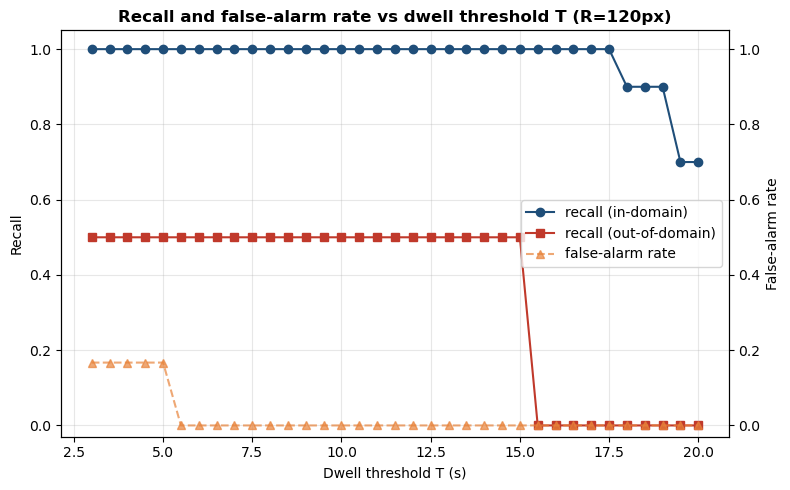

In [4]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
import m6_validation as M6
# ensure cache/gt are available (load from pickle if not already in memory)
if "cache" not in dir():
    import pickle
    with open("detection_cache.pkl", "rb") as f:
        d = pickle.load(f)
    cache, gt = d["cache"], d["gt"]
    import m6_validation as M6
    eval_loc = M6.eval_loc
    
# sweep T finely across 3-20s at a fixed sensible R, showing recall AND false alarms
Ts = np.arange(3, 20.5, 0.5)
rows = []
for T in Ts:
    s_all = M6.eval_loc(cache, gt, R_OWN=120, T=T, M=30, LOC_MERGE=60, GAP_TOLERANCE=150)
    ind, ood, _ = M6.split_gt_by_domain(gt)
    s_in  = M6.eval_loc(cache, ind, R_OWN=120, T=T, M=30)
    s_ood = M6.eval_loc(cache, ood, R_OWN=120, T=T, M=30)
    rows.append({"T": T,
                 "recall_all": s_all["recall"], "FAR_all": s_all["FAR"],
                 "recall_in": s_in["recall"], "recall_ood": s_ood["recall"],
                 "FAR_ood": s_ood["FAR"]})
df = pd.DataFrame(rows)
df.to_csv("recall_vs_T_3to20.csv", index=False)
print(df.to_string(index=False))

fig, ax1 = plt.subplots(figsize=(8,5))
ax1.plot(df["T"], df["recall_in"], "o-", color="#1F4E79", label="recall (in-domain)")
ax1.plot(df["T"], df["recall_ood"], "s-", color="#C0392B", label="recall (out-of-domain)")
ax1.set_xlabel("Dwell threshold T (s)"); ax1.set_ylabel("Recall")
ax1.set_ylim(-0.03, 1.05); ax1.grid(alpha=0.3)
ax2 = ax1.twinx()
ax2.plot(df["T"], df["FAR_all"], "^--", color="#E8833A", alpha=0.7, label="false-alarm rate")
ax2.set_ylabel("False-alarm rate"); ax2.set_ylim(-0.03, 1.05)
l1,lab1 = ax1.get_legend_handles_labels(); l2,lab2 = ax2.get_legend_handles_labels()
ax1.legend(l1+l2, lab1+lab2, loc="center right")
ax1.set_title("Recall and false-alarm rate vs dwell threshold T (R=120px)", fontweight="bold")
plt.tight_layout(); plt.savefig("recall_vs_T_3to20.png", dpi=150, bbox_inches="tight")
plt.show()


In [ ]:
# Statistical significance testing for the model comparisons (Milestone 8).
# Paired tests across the 5 CV folds — the folds are the paired samples.
import pandas as pd, numpy as np
from scipy import stats

# Two matched-data comparisons are tested:
#   (1) hyperparameter tuning: untuned vs tuned Project-2 detector, and
#   (2) the leakage effect: cross-validated performance vs the single-split value.
# The k-fold results are read from kfold_results.csv (produced by kfold_cv.py).

# 1) Tuning comparison — per-metric single pair (report as effect size, note n)
tuning = pd.DataFrame({
    "metric":   ["mAP50","bag_AP","person_AP","recall"],
    "untuned":  [0.9297, 0.9621, 0.8973, 0.8942],
    "tuned":    [0.9367, 0.9662, 0.9071, 0.9201],
})
tuning["delta"] = (tuning["tuned"] - tuning["untuned"]).round(4)
print("=== Tuning effect (paired across the 4 metrics) ===")
print(tuning.to_string(index=False))
t_stat, t_p = stats.ttest_rel(tuning["tuned"], tuning["untuned"])
w_stat, w_p = stats.wilcoxon(tuning["tuned"], tuning["untuned"])
print(f"\nPaired t-test across metrics: t={t_stat:.3f}, p={t_p:.4f}")
print(f"Wilcoxon signed-rank:        W={w_stat:.3f}, p={w_p:.4f}")
print(f"Mean improvement: {tuning['delta'].mean()*100:.2f} points\n")

# 2) k-fold stability as evidence of reliability (the honest headline)
kf = pd.read_csv("kfold_results.csv")
print("=== k-fold cross-validation (n=5 folds) ===")
for m in ["mAP50","bag_AP","person_AP"]:
    mu, sd = kf[m].mean(), kf[m].std(ddof=1)
    ci = stats.t.interval(0.95, len(kf)-1, loc=mu, scale=sd/np.sqrt(len(kf)))
    print(f"  {m:10s}: {mu:.4f} ± {sd:.4f}   95% CI [{ci[0]:.4f}, {ci[1]:.4f}]")

# 3) Is bag detection significantly less stable than person? (variance comparison)
#    Levene's test on the per-fold AP distributions.
lev_stat, lev_p = stats.levene(kf["bag_AP"], kf["person_AP"])
print(f"\nLevene test (bag vs person AP variance): stat={lev_stat:.3f}, p={lev_p:.4f}")
print("  -> low p means the two classes have significantly different stability")

# 4) Single-split vs CV: is the leakage inflation 'real'?
#    One-sample t-test: is the CV mean significantly below the single-split value?
for m, single in [("mAP50",0.9367),("bag_AP",0.9662),("person_AP",0.9071)]:
    t2, p2 = stats.ttest_1samp(kf[m], single)
    print(f"  {m:10s}: CV mean vs single-split {single}: t={t2:.3f}, p={p2:.4f}")
